In [1]:
# Cell 1
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

print("Đã import các thư viện thành công!")

Đã import các thư viện thành công!


In [12]:
# Cell 2
def inspect_npz(file_path):
    print(f"========== ĐANG ĐỌC FILE: {file_path} ==========")
    try:
        data = np.load(file_path, allow_pickle=True)
        print("Các mảng (keys) có trong file:")
        for key in data.files:
            arr = data[key]
            print(f"\n🔹 Biến: '{key}'")
            print(f"  - Kích thước (Shape): {arr.shape}")
            print(f"  - Kiểu dữ liệu: {arr.dtype}")
            print(f"  - Dữ liệu mẫu (2 phần tử đầu): \n{arr[:10]}")
    except Exception as e:
        print(f"Lỗi khi đọc file: {e}")
    print("\n")

# Chạy hàm cho 2 file npz
inspect_npz('graph_structure_20260427_152321.npz')
inspect_npz('osm_graph_20260427_152259.npz')

========== ĐANG ĐỌC FILE: graph_structure_20260427_152321.npz ==========
Các mảng (keys) có trong file:

🔹 Biến: 'node_features'
  - Kích thước (Shape): (1980, 4)
  - Kiểu dữ liệu: float32
  - Dữ liệu mẫu (2 phần tử đầu): 
[[0.00000000e+00 0.00000000e+00 9.14691746e-01 1.70666296e-02]
 [0.00000000e+00 0.00000000e+00 7.94964135e-01 5.81293225e-01]
 [6.00000024e-01 8.07160698e-03 8.74582291e-01 6.33104816e-02]
 [2.00000003e-01 1.34408325e-02 8.31252933e-01 8.96095872e-01]
 [6.00000024e-01 2.69420282e-03 6.56972006e-02 7.87421405e-01]
 [6.00000024e-01 5.19271381e-03 4.30690050e-02 6.73038900e-01]
 [6.00000024e-01 1.22785335e-02 8.58694255e-01 9.04421091e-01]
 [4.00000006e-01 1.10084945e-02 9.63185847e-01 2.36756876e-01]
 [4.00000006e-01 1.76265929e-02 8.07521045e-01 8.85689914e-01]
 [2.00000003e-01 1.12637870e-04 9.05288041e-01 5.57214975e-01]]

🔹 Biến: 'edge_features'
  - Kích thước (Shape): (3697, 11)
  - Kiểu dữ liệu: float32
  - Dữ liệu mẫu (2 phần tử đầu): 
[[ 19.663944    17.443848 

In [13]:
# Cell 3
graphml_path = 'osm_10.7600_106.7150_10.8050_106.6750.graphml'

print(f"========== ĐANG ĐỌC FILE: {graphml_path} ==========")
G = nx.read_graphml(graphml_path)

print(f"Tổng số Nút (Nodes): {G.number_of_nodes()}")
print(f"Tổng số Cạnh (Edges - Đoạn đường): {G.number_of_edges()}")

# Trích xuất thử thông tin của 1 Nút bất kỳ
sample_node = list(G.nodes(data=True))[0]
print(f"\n📍 Thông tin 1 Nút (Node) mẫu:")
print(f"  - ID: {sample_node[0]}")
print(f"  - Thuộc tính: {sample_node[1]}")

# Trích xuất thử thông tin của 1 Cạnh bất kỳ
sample_edge = list(G.edges(data=True))[0]
print(f"\n🛣️ Thông tin 1 Cạnh (Edge) mẫu:")
print(f"  - Nối từ Nút ID: {sample_edge[0]} ---> Đến Nút ID: {sample_edge[1]}")
print(f"  - Thuộc tính đường: {sample_edge[2]}")

========== ĐANG ĐỌC FILE: osm_10.7600_106.7150_10.8050_106.6750.graphml ==========
Tổng số Nút (Nodes): 2692
Tổng số Cạnh (Edges - Đoạn đường): 5878

📍 Thông tin 1 Nút (Node) mẫu:
  - ID: 366368194
  - Thuộc tính: {'y': '10.7902412', 'x': '106.7095438', 'street_count': '3'}

🛣️ Thông tin 1 Cạnh (Edge) mẫu:
  - Nối từ Nút ID: 366368194 ---> Đến Nút ID: 366386086
  - Thuộc tính đường: {'osmid': '544981806', 'highway': 'residential', 'name': 'Phạm Viết Chánh', 'oneway': 'False', 'reversed': 'False', 'length': '92.8759896059378'}


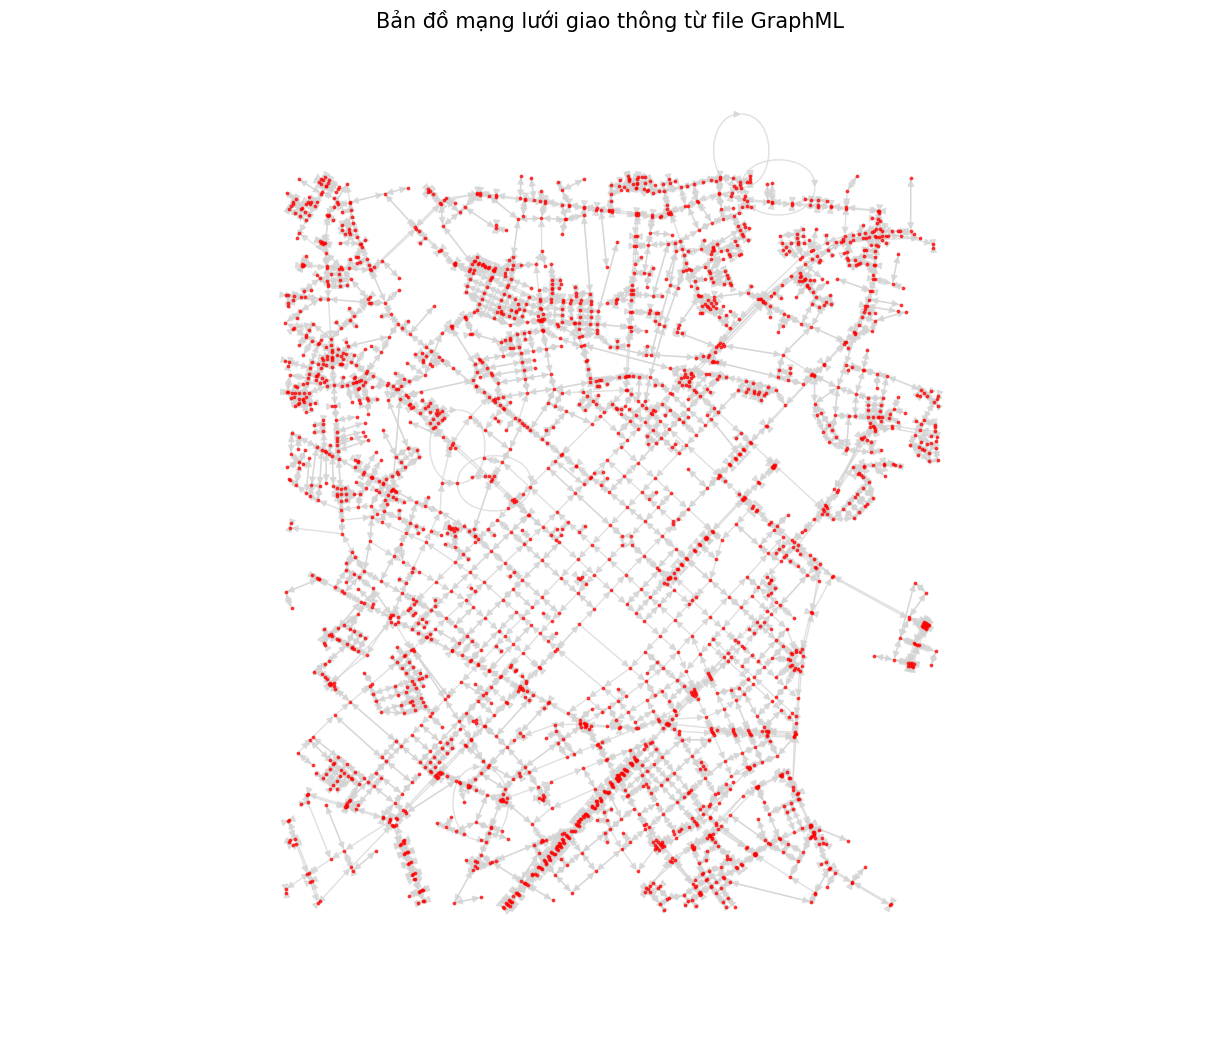

In [14]:
# Cell 4
plt.figure(figsize=(12, 10))

try:
    # Lấy tọa độ x (kinh độ), y (vĩ độ) từ thuộc tính của mỗi node
    pos = {node: (float(data.get('x', 0)), float(data.get('y', 0))) 
           for node, data in G.nodes(data=True)}
    
    # Nếu node không có x, y thì dùng layout mặc định
    if all(v == (0.0, 0.0) for v in pos.values()):
        print("Không tìm thấy tọa độ x,y. Đang dùng layout mặc định (sẽ hơi lộn xộn)...")
        pos = nx.spring_layout(G)
        
    # Vẽ các đoạn đường (edges) màu xám nhạt, các nút (nodes) màu đỏ
    nx.draw(G, pos, node_size=3, node_color='red', edge_color='lightgray', 
            with_labels=False, alpha=0.7)
    
    plt.title("Bản đồ mạng lưới giao thông từ file GraphML", fontsize=15)
    plt.axis('equal') # Giữ tỉ lệ không gian thực tế
    plt.show()
    
except Exception as e:
    print(f"Có lỗi xảy ra khi vẽ biểu đồ: {e}")

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.collections import LineCollection

# Cấu hình đồ thị
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection

# Điền tên file .npz mà bạn muốn phân tích (ví dụ file bạn đang highlight)
file_path = 'osm_graph_20260427_152259.npz' 

try:
    # Load file nén .npz
    data = np.load(file_path, allow_pickle=True)
    print(f"✅ Đã load thành công {file_path}!\n")
    
    # In ra danh sách các mảng dữ liệu có bên trong file
    print("📂 Các thành phần có trong file nén:")
    print(data.files)
    print("-" * 30)
    
    # Hàm hỗ trợ trích xuất dữ liệu (vì key có thể kèm đuôi .npy hoặc không)
    def get_array(npz_file, base_name):
        if base_name in npz_file:
            return npz_file[base_name]
        elif f"{base_name}.npy" in npz_file:
            return npz_file[f"{base_name}.npy"]
        else:
            return None

    # Giải nén các biến cấu trúc đồ thị
    osm_node_ids = get_array(data, 'osm_node_ids')
    coords = get_array(data, 'coordinates')
    edge_index = get_array(data, 'edge_index')
    adj_matrix = get_array(data, 'adjacency_matrix')
    
    # Giải nén các biến đặc trưng (features)
    node_features = get_array(data, 'node_features')
    edge_lengths = get_array(data, 'edge_lengths')
    edge_maxspeed = get_array(data, 'edge_maxspeed')
    edge_lanes = get_array(data, 'edge_lanes')
    
    # Sanity check nhanh
    if coords is not None:
        print(f"📍 Kích thước Coordinates: {coords.shape}")
    if edge_index is not None:
        print(f"🔗 Kích thước Edge Index: {edge_index.shape}")
        
except FileNotFoundError:
    print(f"❌ Lỗi: Không tìm thấy file '{file_path}'. Hãy đảm bảo tên file chính xác và nằm cùng thư mục với notebook.")

✅ Đã load thành công osm_graph_20260427_152259.npz!

📂 Các thành phần có trong file nén:
['osm_node_ids', 'coordinates', 'edge_index', 'edge_osmids', 'edge_lengths', 'edge_maxspeed', 'edge_lanes', 'edge_highway_type', 'adjacency_matrix', 'node_features', 'feature_names', '_metadata']
------------------------------
📍 Kích thước Coordinates: (2692, 2)
🔗 Kích thước Edge Index: (2, 5878)
